In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

In [2]:
from google.colab import drive
drive.mount('/content/drive')

folder_path = "/content/drive/MyDrive/DS310/Dataset/merged_data/"

Mounted at /content/drive


In [3]:
train_df = pd.read_csv(folder_path + "train.csv")
val_df = pd.read_csv(folder_path + "val.csv")
test_df = pd.read_csv(folder_path + "test.csv")

In [4]:
X_train = train_df['full_story']
y_train = train_df['category'].astype('category').cat.codes

X_val = val_df['full_story']
y_val = val_df['category'].astype('category').cat.codes

X_test = test_df['full_story']
y_test = test_df['category'].astype('category').cat.codes

In [5]:
# Lưu mapping nhãn
label_mapping = dict(enumerate(train_df['category'].astype('category').cat.categories))

In [6]:
# Vector hóa full_story
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test)

In [7]:
# Huấn luyện Logistic Regression
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_vec, y_train)

LogisticRegression(max_iter=1000)

In [8]:
# Dự đoán trên validation & test
y_val_pred = clf.predict(X_val_vec)
y_test_pred = clf.predict(X_test_vec)

In [9]:
# Đánh giá
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=[label_mapping[i] for i in range(len(label_mapping))]))

Validation Accuracy: 0.4784727863525589
Test Accuracy: 0.4724025974025974

Classification Report (Test Set):
                    precision    recall  f1-score   support

 business_industry       0.68      0.74      0.71       103
     computer_math       0.43      0.39      0.41       102
     earth_climate       0.35      0.38      0.37       103
education_learning       0.58      0.63      0.60       103
     fossils_ruins       0.60      0.66      0.63       103
   health_medicine       0.32      0.35      0.33       103
       living_well       0.23      0.21      0.22       102
     matter_energy       0.47      0.44      0.45       103
        mind_brain       0.33      0.35      0.34       102
    plants_animals       0.37      0.36      0.37       102
   science_society       0.32      0.23      0.27       103
        space_time       0.86      0.92      0.89       103

          accuracy                           0.47      1232
         macro avg       0.46      0.47      0.47

Nhận xét:

- Mô hình dự đoán tốt với space_time và business_industry, khá với education_learning, fossils_ruins.

- Lớp living_well, science_society, health_medicine rất khó, F1-score thấp (<0.35).

- Các lớp khó chủ yếu là các chủ đề trừu tượng hoặc ít dữ liệu → dễ nhầm lẫn.

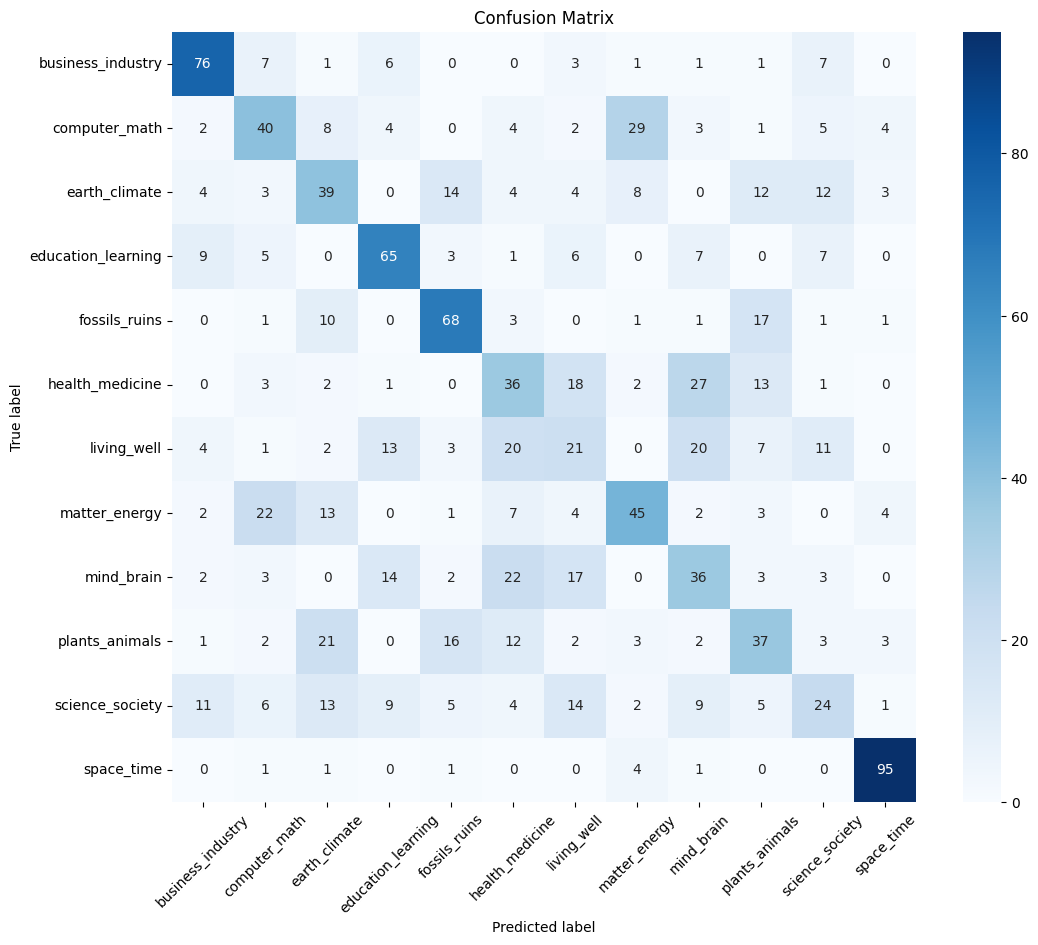

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

class_names = [
    "business_industry", "computer_math", "earth_climate", "education_learning",
    "fossils_ruins", "health_medicine", "living_well", "matter_energy",
    "mind_brain", "plants_animals", "science_society", "space_time"
]

# Tạo confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

# Vẽ heatmap
plt.figure(figsize=(12,10))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()